<a href="https://colab.research.google.com/github/spqdot/lab-image-classification-using-convolutional-neural-networks/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
# Your code here :
x_train.shape

(50000, 32, 32, 3)

In [4]:
x_test.shape

(10000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_test.shape

(10000, 1)

###

###

### Visualize 10 random samples from each class

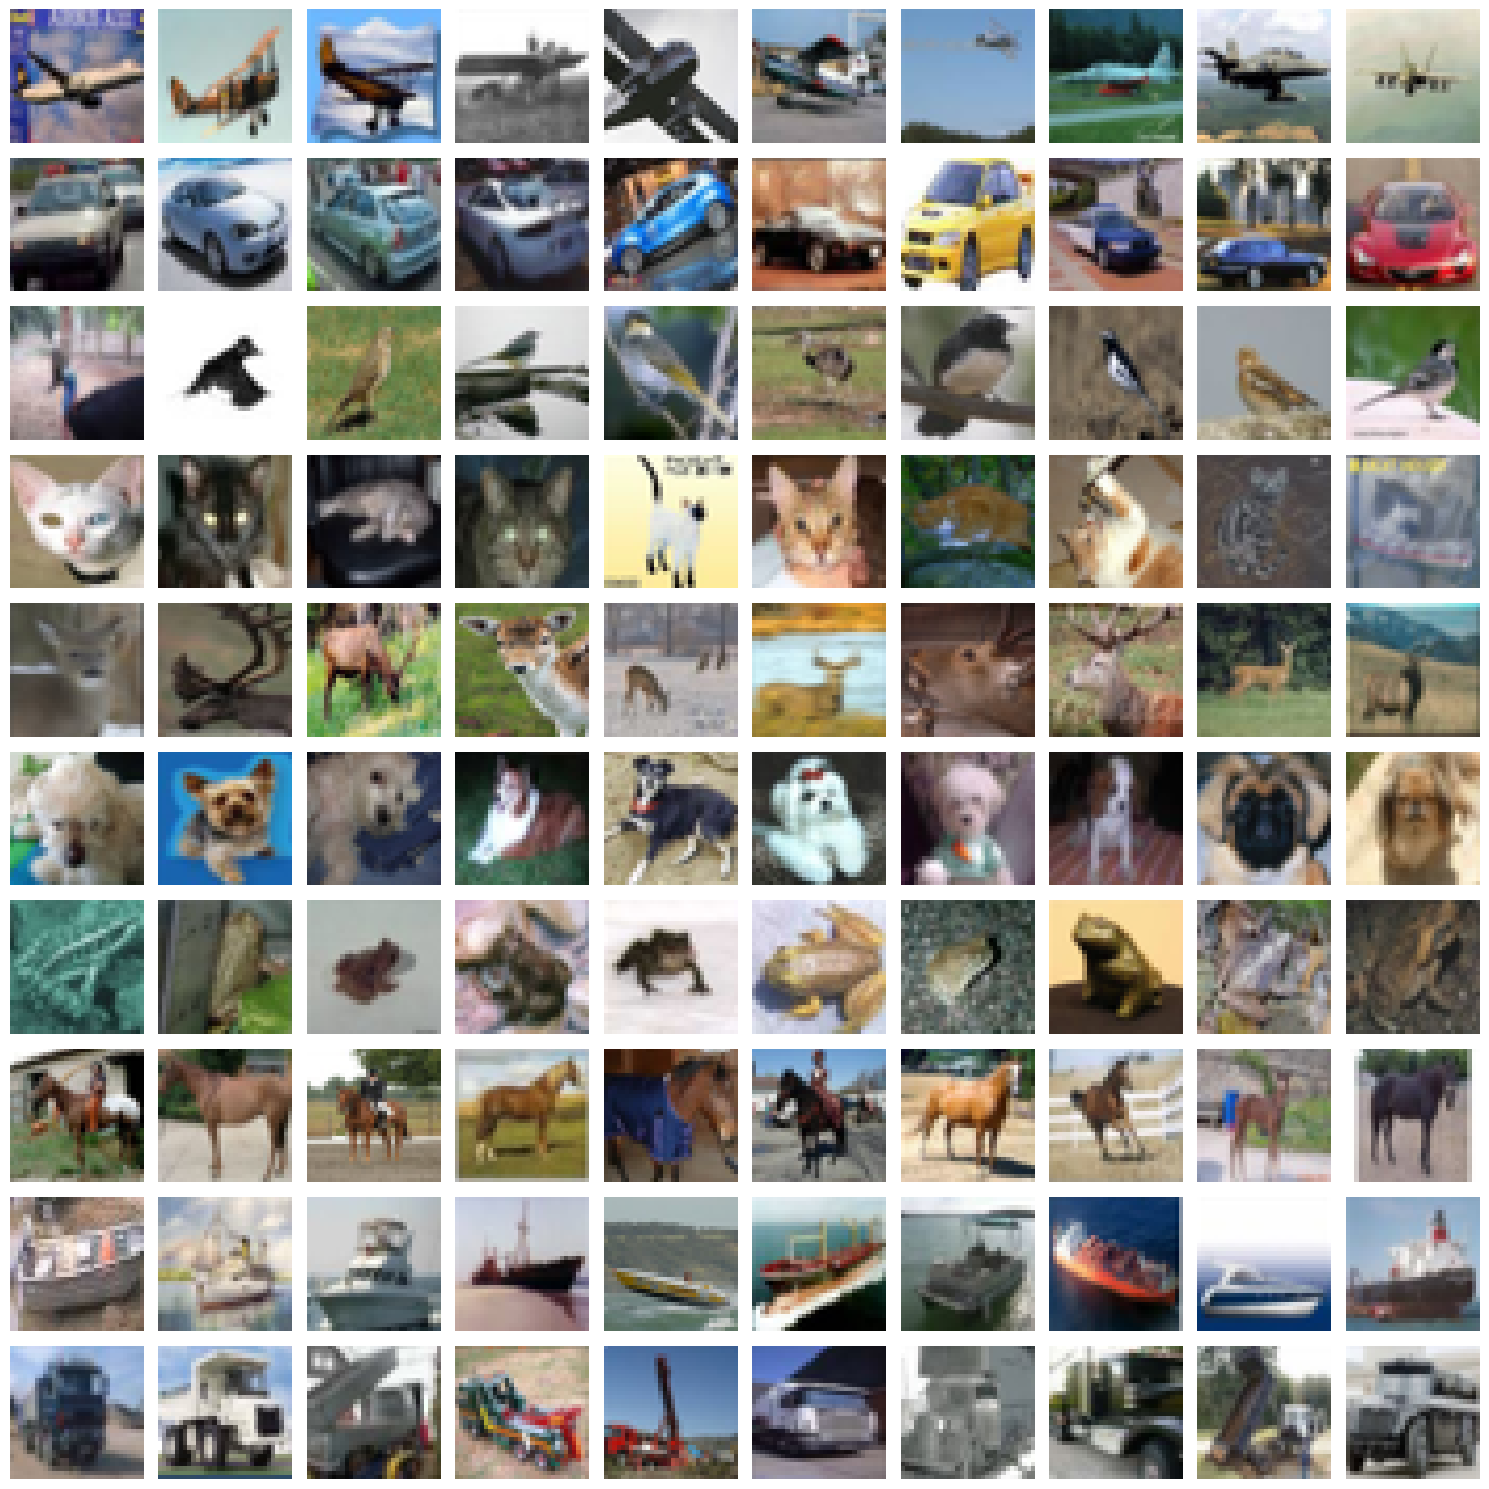

In [26]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

## Create a 10 × 10 grid:

fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for i in range(10):
    # Get indices of images belonging to class i
    idx = np.where(y_train.flatten() == i)[0]

    # Select 10 random images
    random_idx = np.random.choice(idx, 10, replace=False)

    for j, image_idx in enumerate(random_idx):
        axes[i, j].imshow(x_train[image_idx])
        axes[i, j].axis('off')

        if j == 0:
            axes[i, j].set_ylabel(class_names[i], fontsize=12)

plt.tight_layout()
plt.show()

### Convert labels to one-hot encoding

In [27]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train[:5])

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Normalize the images

In [28]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [29]:
x_train[:5]

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [30]:
x_test[:5]

array([[[[0.61960787, 0.4392157 , 0.19215687],
         [0.62352943, 0.43529412, 0.18431373],
         [0.64705884, 0.45490196, 0.2       ],
         ...,
         [0.5372549 , 0.37254903, 0.14117648],
         [0.49411765, 0.35686275, 0.14117648],
         [0.45490196, 0.33333334, 0.12941177]],

        [[0.59607846, 0.4392157 , 0.2       ],
         [0.5921569 , 0.43137255, 0.15686275],
         [0.62352943, 0.44705883, 0.1764706 ],
         ...,
         [0.53333336, 0.37254903, 0.12156863],
         [0.49019608, 0.35686275, 0.1254902 ],
         [0.46666667, 0.34509805, 0.13333334]],

        [[0.5921569 , 0.43137255, 0.18431373],
         [0.5921569 , 0.42745098, 0.12941177],
         [0.61960787, 0.43529412, 0.14117648],
         ...,
         [0.54509807, 0.38431373, 0.13333334],
         [0.50980395, 0.37254903, 0.13333334],
         [0.47058824, 0.34901962, 0.12941177]],

        ...,

        [[0.26666668, 0.4862745 , 0.69411767],
         [0.16470589, 0.39215687, 0.5803922 ]

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [12]:
from keras.backend import clear_session
clear_session()

In [31]:
from tensorflow.keras import models, layers



In [32]:
# Your code here :
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [34]:
# Your code here :

model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.1)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.1867 - loss: 2.2467 - val_accuracy: 0.2338 - val_loss: 2.1902
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2570 - loss: 2.1329 - val_accuracy: 0.2688 - val_loss: 2.0804
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2929 - loss: 2.0324 - val_accuracy: 0.3064 - val_loss: 2.0054
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3124 - loss: 1.9659 - val_accuracy: 0.3178 - val_loss: 1.9537
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3297 - loss: 1.9232 - val_accuracy: 0.3348 - val_loss: 1.9140
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3438 - loss: 1.8914 - val_accuracy: 0.3450 - val_loss: 1.8834
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3544 - loss: 1.8626 - val_accuracy: 0.3516 - val_loss: 1.8628
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3638 - loss: 1.8369 - val_accuracy: 0.3662 - v

*   Plot the cross entropy loss curve and the accuracy curve

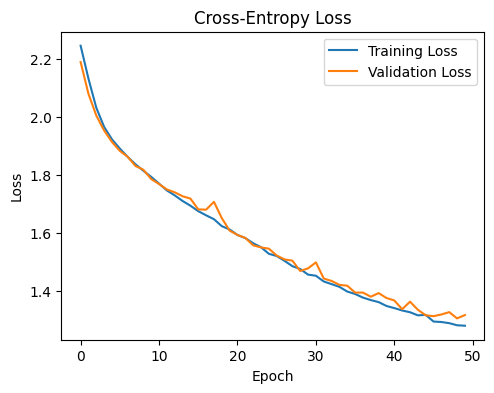

In [35]:
# Your code here :
plt.figure(figsize=(12, 4))


# Cross-Entropy Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()




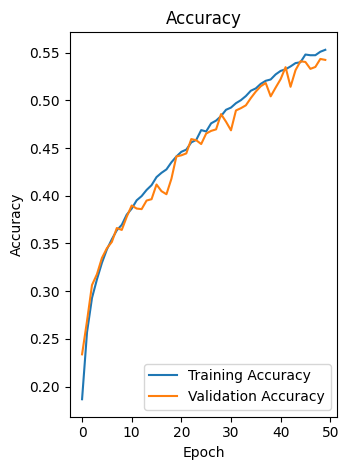

In [36]:
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [37]:
from keras.backend import clear_session
clear_session()

In [38]:
# Your code here :
from tensorflow.keras import models, layers
model_VGG = models.Sequential()
model_VGG.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model_VGG.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model_VGG.add(layers.MaxPooling2D((2, 2)))
model_VGG.add(layers.Flatten())
model_VGG.add(layers.Dense(128, activation='relu'))
model_VGG.add(layers.Dense(10, activation='softmax'))


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [39]:
# Your code here :

model_VGG.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

history_VGG = model_VGG.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.1)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.1586 - loss: 2.2635 - val_accuracy: 0.2028 - val_loss: 2.2055
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2450 - loss: 2.1296 - val_accuracy: 0.2680 - val_loss: 2.0592
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2855 - loss: 2.0136 - val_accuracy: 0.3020 - val_loss: 1.9922
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3276 - loss: 1.9316 - val_accuracy: 0.3248 - val_loss: 1.9380
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3428 - loss: 1.8793 - val_accuracy: 0.3578 - val_loss: 1.8369
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3626 - loss: 1.8297 - val_accuracy: 0.3538 - val_loss: 1.8176
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3707 - loss: 1.7978 - val_accuracy: 0.3692 - val_loss: 1.8064
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3820 - loss: 1.7664 - val_accuracy: 0.3858 - 

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


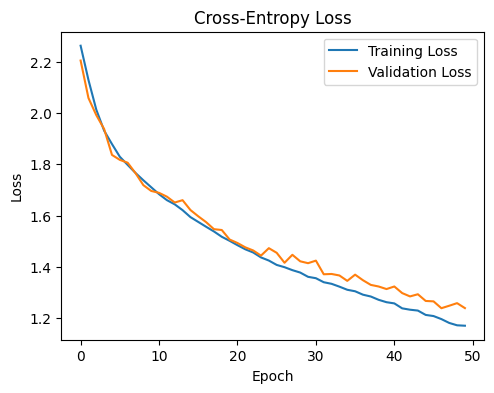

In [42]:
# Your code here :
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_VGG.history['loss'], label='Training Loss')
plt.plot(history_VGG.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

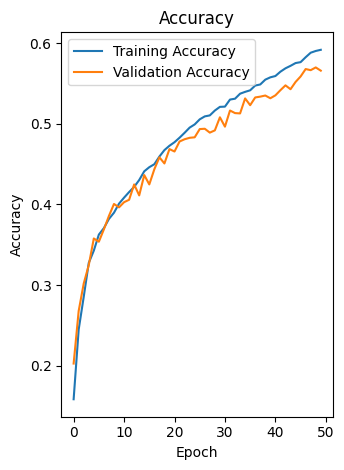

In [43]:
# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(history_VGG.history['accuracy'], label='Training Accuracy')
plt.plot(history_VGG.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Comment on the observation**

*(Double-click or enter to edit)*




*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [44]:
# Your code here :
from sklearn.metrics import confusion_matrix
import seaborn as sns
model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


array([[5.4053399e-03, 6.3177110e-03, 2.1448469e-02, ..., 8.5729780e-04,
        2.2540364e-02, 2.2110750e-03],
       [1.6396759e-01, 2.2790778e-01, 5.3278648e-04, ..., 5.6828168e-05,
        5.6643021e-01, 4.0300820e-02],
       [3.1479302e-01, 9.1620043e-02, 8.0568204e-03, ..., 2.6068969e-03,
        5.1738614e-01, 4.8237201e-02],
       ...,
       [4.3915826e-04, 2.9583677e-04, 8.9484550e-02, ..., 4.3056231e-02,
        1.1418830e-03, 5.6387257e-04],
       [3.3639971e-02, 6.0235046e-02, 5.1207345e-02, ..., 3.6944643e-02,
        6.4385752e-03, 1.2643227e-02],
       [3.1556259e-03, 3.6514673e-04, 4.1086674e-02, ..., 4.5109457e-01,
        2.1967356e-04, 1.8410046e-03]], dtype=float32)

In [45]:
confusion_matrix(np.argmax(y_test, axis=1), np.argmax(model.predict(x_test), axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[528,  34,  89,  32,  29,  12,  47,  18, 178,  33],
       [ 40, 623,  18,  21,  12,  14,  47,  22,  79, 124],
       [ 58,  15, 378,  82, 145,  68, 168,  51,  26,   9],
       [ 18,  11,  72, 378,  91, 131, 211,  49,  19,  20],
       [ 24,   7, 100,  61, 497,  46, 185,  60,  14,   6],
       [  8,   4,  77, 216,  95, 389, 115,  76,  16,   4],
       [  1,   7,  43,  56,  72,  16, 774,  21,   5,   5],
       [ 13,   6,  36,  71, 109,  71,  84, 581,  10,  19],
       [ 87,  60,  30,  22,  19,  15,  25,  12, 690,  40],
       [ 46, 128,  13,  35,  14,  21,  68,  56,  83, 536]])

In [46]:
model_VGG.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([[5.9461803e-03, 2.7747659e-03, 3.8042311e-02, ..., 4.2603961e-03,
        1.4105181e-02, 1.1667209e-03],
       [1.4190671e-01, 6.6954327e-01, 9.7052928e-04, ..., 1.8149554e-05,
        1.5275007e-01, 3.4309130e-02],
       [3.9701688e-01, 2.2449608e-01, 4.1813860e-03, ..., 2.5048926e-03,
        3.1656161e-01, 4.8777297e-02],
       ...,
       [2.3515701e-04, 4.1257424e-04, 2.6738346e-01, ..., 1.8941313e-02,
        6.1119292e-03, 8.8657654e-04],
       [1.5584184e-01, 2.3944853e-01, 9.1095775e-02, ..., 1.9000625e-02,
        8.8959150e-03, 3.1931438e-02],
       [7.4047847e-03, 2.9703616e-03, 9.3770966e-02, ..., 4.8813194e-01,
        1.0332161e-03, 4.0088743e-03]], dtype=float32)

In [47]:
confusion_matrix(np.argmax(y_test, axis=1), np.argmax(model_VGG.predict(x_test), axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[689,  40,  61,   8,  17,   8,  29,  10, 116,  22],
       [ 55, 756,  14,   7,   5,   4,  16,   6,  53,  84],
       [ 88,  23, 512,  33, 104,  45, 106,  43,  30,  16],
       [ 39,  24, 125, 276,  99, 159, 171,  43,  33,  31],
       [ 45,  15, 161,  26, 500,  32, 139,  52,  21,   9],
       [ 27,   9, 143, 138,  83, 411,  87,  69,  22,  11],
       [ 11,  22,  71,  24,  83,  17, 729,  18,  18,   7],
       [ 49,  19,  63,  34,  88,  69,  40, 587,  13,  38],
       [126,  81,  26,   4,  12,   9,  13,   7, 689,  33],
       [ 61, 235,  25,  16,   8,  10,  22,  26,  59, 538]])

**Comment here :**

*(Double-click or enter to edit)*
The VGG model's training and validation accuracy curves lie above those of the simple CNN.
The deeper VGG network performs better because:

More convolutional layers allow the network to learn more complex and hierarchical features.
Small 3×3 filters stacked together capture richer patterns than a shallow network.
The model has a higher representational capacity, leading to better classification performance on the CIFAR-10 dataset.

However, the improvement is not dramatic (about 3–4%). This suggests that:

The VGG model may not be deep enough to fully exploit the dataset, or
Additional techniques such as  Dropout and Learning Rate Scheduling could further improve performance.

...

*    Print the test accuracy for the trained model.

In [48]:
# Your code here :

### Evaluste the simple model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5374 - loss: 1.3217
Test Loss: 1.3216599225997925
Test Accuracy: 0.5374000072479248


In [49]:
### Evaluste the VGG model
test_loss, test_accuracy = model_VGG.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5687 - loss: 1.2317
Test Loss: 1.2317315340042114
Test Accuracy: 0.5687000155448914


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [11]:
from keras.backend import clear_session
clear_session()

### Resize the images to 64×64

In [7]:
import tensorflow as tf

x_train = tf.image.resize(x_train, (64, 64)).numpy()
x_test = tf.image.resize(x_test, (64, 64)).numpy()

print(x_train.shape)
print(x_test.shape)

(50000, 64, 64, 3)
(10000, 64, 64, 3)


In [8]:
### Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [9]:
### One_hot_encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [10]:
# Your code here :
from tensorflow.keras import models, layers

model_VGG_complete = models.Sequential()
model_VGG_complete.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64,3)))
model_VGG_complete.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model_VGG_complete.add(layers.MaxPooling2D((2, 2)))
model_VGG_complete.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model_VGG_complete.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model_VGG_complete.add(layers.MaxPooling2D((2, 2)))
model_VGG_complete.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model_VGG_complete.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model_VGG_complete.add(layers.MaxPooling2D((2, 2)))
model_VGG_complete.add(layers.Flatten())
model_VGG_complete.add(layers.Dense(128, activation='relu'))
model_VGG_complete.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [11]:
model_VGG_complete.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

history_VGG_complete = model_VGG_complete.fit(x_train, y_train_cat, epochs=10, batch_size=512, validation_split=0.1)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.1046 - loss: 2.2998 - val_accuracy: 0.1228 - val_loss: 2.2961
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 400ms/step - accuracy: 0.1360 - loss: 2.2921 - val_accuracy: 0.1298 - val_loss: 2.2846
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 399ms/step - accuracy: 0.1550 - loss: 2.2684 - val_accuracy: 0.2010 - val_loss: 2.2355
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 398ms/step - accuracy: 0.2188 - loss: 2.1710 - val_accuracy: 0.2420 - val_loss: 2.1074
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 399ms/step - accuracy: 0.2549 - loss: 2.0782 - val_accuracy: 0.2476 - val_loss: 2.1071
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 399ms/step - accuracy: 0.2954 - loss: 1.9947 - val_accuracy: 0.3290 - val_loss: 1.9131
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 399ms/step - accuracy: 0.3218 - loss: 1.9161 - val_accuracy: 0.3310 - val_loss: 1.8541
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 399ms/step - accuracy: 0.3442 - loss: 1.8612 - val_accura

In [12]:
model_VGG_complete.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


array([[0.01220873, 0.02330382, 0.10394602, ..., 0.01121913, 0.05711885,
        0.0061382 ],
       [0.06208784, 0.178266  , 0.01087692, ..., 0.00258331, 0.397342  ,
        0.31693822],
       [0.06382895, 0.0897845 , 0.01263842, ..., 0.0101109 , 0.5501928 ,
        0.2250366 ],
       ...,
       [0.00933533, 0.00420633, 0.07076495, ..., 0.08629158, 0.01612108,
        0.00936808],
       [0.01907199, 0.02876242, 0.05787718, ..., 0.05162288, 0.01374855,
        0.02693949],
       [0.01775857, 0.02116071, 0.05424737, ..., 0.6383073 , 0.00401745,
        0.03266358]], dtype=float32)

In [14]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
confusion_matrix(np.argmax(y_test_cat, axis=1), np.argmax(model_VGG_complete.predict(x_test), axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


array([[333,  30,  27,  89,   1,  61,  25,  68, 304,  62],
       [ 18, 358,  14,  70,   4, 103,  76,  60, 110, 187],
       [ 54,  33, 205, 160,  33, 187, 158,  92,  60,  18],
       [  6,  25,  47, 356,  25, 274, 142,  53,  32,  40],
       [ 23,   5, 159, 108, 163, 139, 256,  89,  40,  18],
       [  0,  17,  66, 233,  29, 439, 102,  57,  36,  21],
       [  2,   8, 100, 171,  41, 103, 525,  20,   7,  23],
       [ 12,  20,  50, 111,  60, 153,  52, 440,  37,  65],
       [ 30,  34,   3,  56,   2,  81,  21,  32, 646,  95],
       [ 18,  89,   6,  99,   2,  58,  51,  80, 130, 467]])

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:
Activation functions introduce non-linearity into a neural network.
Without activation functions, a neural network would simply perform a series of linear transformations:
y =x1.w1 + x2.w2 + x3.w3 +b
which can be simplified into a single linear equation. In that case, even a very deep network would behave like simple linear regression and would not be able to learn complex patterns.


2 - Key Differences between sigmoid and softmax:

Sigmoid activation function is used in outpput layer for Binary classification.

Softmax activation function is used in output layer for Multi-label classification.



_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:
Binary Crossentropy (BCE) is Used when there are two classes.

Examples:

Spam vs Not Spam
Fraud vs Not Fraud
Cat vs Dog

Categorical Crossentropy (CCE) is used when there are more than two mutually exclusive classes.

Examples:

CIFAR-10
Handwritten digit recognition
Flower species classification


